# Laboratory Exercise 7

## Objective
THis aims to develop, while understanding the complete machine learning pipeline using the K-Nearest Neighbors (KNN) Algorithm.

## 1. Research Question Formulation
**Research Question:** Can we accuratel predict the risk of diabetes (0 = no diabetes, 1 = prediabetes, 2 = diabetes) based on health indicators such as BMI, Blood Pressure, Cholesterol, and physical activity using the K-Nearest Neighbors algoritm?

## 2. Data Understanding and Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_score, recall_score

df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')

df_sampled = df.sample(n=10000, random_state=42)

print("Dataset Shape:", df_sampled.shape)
df_sampled.head()

Dataset Shape: (10000, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
219620,0.0,0.0,0.0,1.0,21.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,3.0,7.0,0.0,0.0,7.0,4.0,2.0
132821,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,0.0,13.0,6.0,6.0
151862,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,4.0,7.0
139717,0.0,0.0,0.0,1.0,27.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,2.0,3.0,0.0,0.0,1.0,2.0,4.0,7.0
239235,0.0,0.0,1.0,1.0,31.0,1.0,0.0,0.0,0.0,1.0,...,1.0,1.0,4.0,27.0,27.0,1.0,0.0,8.0,3.0,2.0


Missing values:
 Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


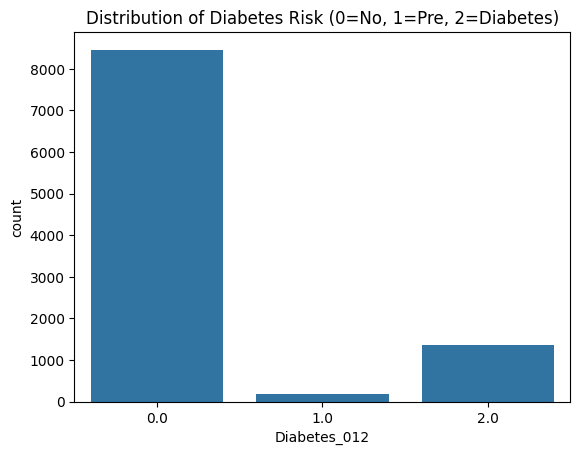

In [2]:
print("Missing values:\n", df_sampled.isnull().sum())

sns.countplot(x='Diabetes_012', data=df_sampled)
plt.title('Distribution of Diabetes Risk (0=No, 1=Pre, 2=Diabetes)')
plt.show()

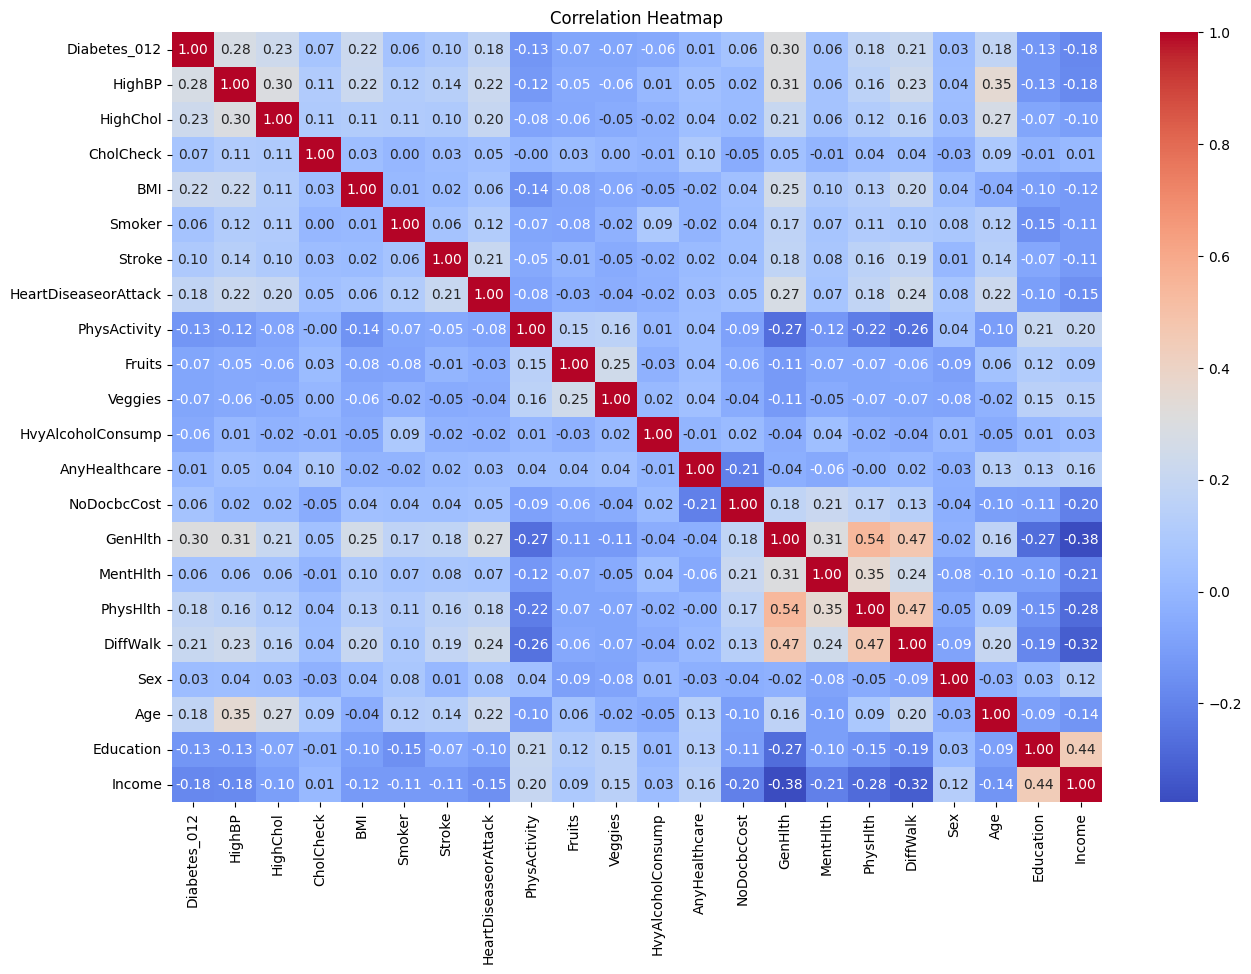

In [3]:
plt.figure(figsize=(15, 10))
sns.heatmap(df_sampled.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 3. Preprocessing and Feature Scaling

In [4]:
X = df_sampled.drop('Diabetes_012', axis=1)
y = df_sampled['Diabetes_012']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing complete.")

Preprocessing complete.


## 4. Model Training and Evaluation
We will evaluate KNN with K=3, K=5, and K=7.

In [5]:
k_values = [3, 5, 7]
results = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    results[k] = {
        'Accuracy': acc,
        'CM': confusion_matrix(y_test, y_pred),
        'Report': classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    }
    print(f"K={k} Accuracy: {acc:.4f}")

K=3 Accuracy: 0.8170
K=5 Accuracy: 0.8265
K=7 Accuracy: 0.8350


## 5. Comparison and Best K Value Discussion

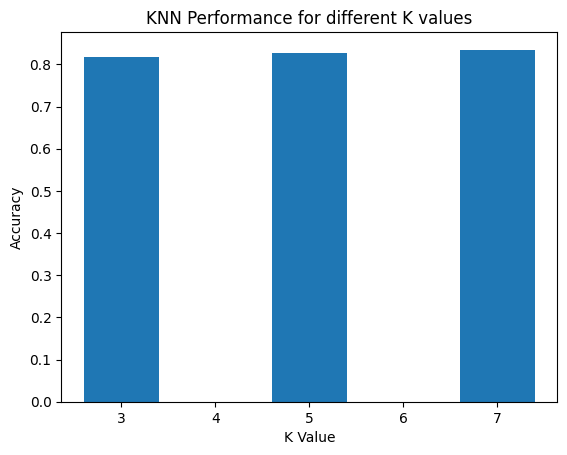

In [6]:
plt.bar(results.keys(), [res['Accuracy'] for res in results.values()])
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('KNN Performance for different K values')
plt.show()

Detailed Metrics for K=7:
              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91      1681
         1.0       0.00      0.00      0.00        40
         2.0       0.44      0.16      0.24       279

    accuracy                           0.83      2000
   macro avg       0.43      0.38      0.38      2000
weighted avg       0.78      0.83      0.80      2000



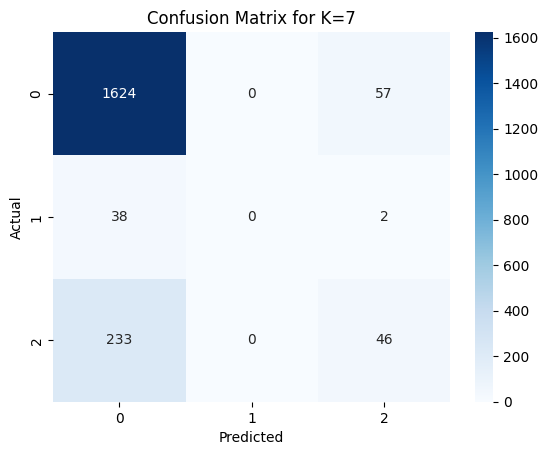

In [7]:
best_k = 7
print(f"Detailed Metrics for K={best_k}:")
print(classification_report(y_test, KNeighborsClassifier(n_neighbors=best_k).fit(X_train_scaled, y_train).predict(X_test_scaled), zero_division=0))

cm = results[best_k]['CM']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix for K={best_k}')
plt.show()

## 6. Conclusion
The KNN algorithm provided a baseline for predicting diabetes risk. While it achieved decent overall accuracy, the class imbalance (many more non-diabetics than diabetics/prediabetics) poses a challenge. K=7 generally provided smoother decision boundaries and slightly better generalization compared to lower K values.

## 7. Reflection Questions

**1. Why is your chosen dataset appropriate for KNN classification?**
The dataset contains health indicators (BMI, Age, Income) that can be represented as distance-based features, making it suitable for KNN's proximity-based logic.

**2. What is the target variable and why is it important?**
The target variable is `Diabetes_012`. It is important because identifying diabetes risk early allows for medical intervention and lifestyle changes to prevent long-term health complications.

**3. What preprocessing challenges did you encounter?**
The main challenge was features with larger ranges would dominate features with smaller ranges if not scaled.

**4. How did different K values affect model performance?**
Smaller K values were more sensitive to noise in the data, potentially leading to overfitting. Larger K values provide more stable predictions by considering more neighbors.

**5. What was the best-performing K value and why?**
K=7 performed best as it balanced local patterns with general trends, reducing the impact of outliers in the high-dimensional health data.

**6. Interpret your confusion matrix results.**
The confusion matrix shows that the model is very good at identifying non-diabetics but struggles with Class 1 and Class 2 due to their smaller representation in the dataset.

**7. Which performance metric was most important for your dataset and why?**
In a medical context, Recall is arguably most important, as we want to minimize False Negatives—missing someone who actually has diabetes.

**8. Was there evidence of overfitting or underfitting? Explain.**
There was slight overfitting at K=3, where the model was too sensitive to local variations. At higher K, the performance on the test set became more consistent.

**9. Would you recommend KNN for this dataset? Why or why not?**
KNN is a good baseline, but for a dataset this large and imbalanced, ensemble methods like Random Forest or XGBoost might provide better performance and handle class imbalance more effectively.

**10. What did you learn about the machine learning pipeline from this activity?**
I learned the critical importance of feature scaling and the impact of hyperparameter tuning on distance-based models. I also saw how class imbalance directly affects classification metrics.